# Mini-TP 5 — Federa tu modelo y mide el trade-off (starter)

**Operaciones de Aprendizaje Automático II · CEIA – FIUBA · Entrega individual, esta semana**

Corre una **simulación federada** con FedAvg y **analiza el trade-off privacidad vs performance**. Las celdas de la actividad fueron completadas en esta versión.

**Qué debes entregar**
1. Reparte un dataset (**el tuyo** o el provisto) entre **K clientes** y corre FedAvg.
2. Compara la accuracy **federada** contra la **centralizada**.
3. Repite con una partición **non-IID** y observa la diferencia (grafica accuracy vs ronda).
4. **Analiza el trade-off:** ¿cuánto accuracy “cuesta” no mover el dato? ¿y sumar privacidad?
5. **(Opcional)** Agrega ruido (privacidad diferencial simple) y mide el impacto.

**Se evalúa:** que corra de punta a punta; FedAvg bien implementado; comparación IID / non-IID / centralizado; y la reflexión sobre el trade-off.

> Apóyate en `federated_tutorial.ipynb`. Entorno uv: `uv add scikit-learn numpy matplotlib`.


In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn", "numpy", "matplotlib"])
print("Listo.")

Listo.


## 1. Datos y modelo

Puedes usar **tu** dataset (el de tu modelo) o el `digits` provisto para practicar la mecánica. El modelo softmax de abajo sirve como base; si usas tu modelo, adapta las funciones.

In [2]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

rng = np.random.RandomState(0)
# Se usa el dataset provisto para que el TP sea autocontenido y reproducible.
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
N_FEAT, N_CLS = X.shape[1], len(np.unique(y))

def init_modelo(): return np.zeros((N_FEAT, N_CLS)), np.zeros(N_CLS)
def softmax(Z): Z=Z-Z.max(1,keepdims=True); e=np.exp(Z); return e/e.sum(1,keepdims=True)
def onehot(y): O=np.zeros((len(y),N_CLS)); O[np.arange(len(y)),y]=1; return O
def paso_sgd(W,b,X,y,lr): P=softmax(X@W+b); D=(P-onehot(y))/len(y); return W-lr*(X.T@D), b-lr*D.sum(0)
def accuracy(W,b,X=Xte,y=yte): return (np.argmax(X@W+b,1)==y).mean()
print("Datos:", Xtr.shape, "· clases:", N_CLS)


Datos: (1347, 64) · clases: 10


## 2. Centralizado (línea de base)

In [3]:
def entrenar_centralizado(epocas=200, lr=0.5):
    W,b=init_modelo()
    for _ in range(epocas): W,b=paso_sgd(W,b,Xtr,ytr,lr)
    return W,b
Wc,bc=entrenar_centralizado(); acc_central=accuracy(Wc,bc)
print(f"accuracy centralizada: {acc_central:.3f}")

accuracy centralizada: 0.969


## 3. FedAvg

Completa el entrenamiento local y la agregación (o reúsalos del tutorial).

In [4]:
def entrenar_local(W_glob, b_glob, Xc, yc, epocas=25, lr=0.5):
    W, b = W_glob.copy(), b_glob.copy()
    for _ in range(epocas):
        W, b = paso_sgd(W, b, Xc, yc, lr)
    return W, b, len(Xc)

def fedavg(actualizaciones):
    # FedAvg: promedio ponderado por la cantidad de ejemplos de cada cliente.
    n_total = sum(nk for _, _, nk in actualizaciones)
    W = sum((nk / n_total) * Wk for Wk, _, nk in actualizaciones)
    b = sum((nk / n_total) * bk for _, bk, nk in actualizaciones)
    return W, b

def federado(clientes, R=20, frac=0.4, epocas=25, lr=0.5, seed=0):
    rng_fed = np.random.RandomState(seed)
    W, b = init_modelo()
    K = len(clientes)
    m = max(1, int(frac * K))
    hist = []
    for _ in range(R):
        sel = rng_fed.choice(K, m, replace=False)
        ups = [entrenar_local(W, b, *clientes[i][:2], epocas, lr) for i in sel]
        W, b = fedavg(ups)
        hist.append(accuracy(W, b))
    return W, b, hist

print("FedAvg listo.")


FedAvg listo.


## 4. Particiones IID y non-IID

In [5]:
def particionar_iid(K, seed=0):
    rng_part = np.random.RandomState(seed)
    idx = rng_part.permutation(len(Xtr))
    return [(Xtr[c], ytr[c]) for c in np.array_split(idx, K)]

def particionar_no_iid(K, clases_por_cliente=2, seed=0):
    rng_part = np.random.RandomState(seed)
    order = np.argsort(ytr)
    shards = list(np.array_split(order, K * clases_por_cliente))
    rng_part.shuffle(shards)
    out = []
    for k in range(K):
        idx = np.concatenate(shards[k*clases_por_cliente:(k+1)*clases_por_cliente])
        out.append((Xtr[idx], ytr[idx]))
    return out

K = 10
clientes_iid = particionar_iid(K, seed=0)
clientes_niid = particionar_no_iid(K, clases_por_cliente=2, seed=0)
_, _, hist_iid  = federado(clientes_iid, seed=0)
_, _, hist_niid = federado(clientes_niid, seed=0)

print(f"central={acc_central:.3f} | IID={hist_iid[-1]:.3f} | non-IID={hist_niid[-1]:.3f}")
print(f"pérdida IID vs central    = {acc_central-hist_iid[-1]:.3f}")
print(f"pérdida non-IID vs central= {acc_central-hist_niid[-1]:.3f}")


central=0.969 | IID=0.967 | non-IID=0.953
pérdida IID vs central    = 0.002
pérdida non-IID vs central= 0.016


## 5. Grafica accuracy vs ronda

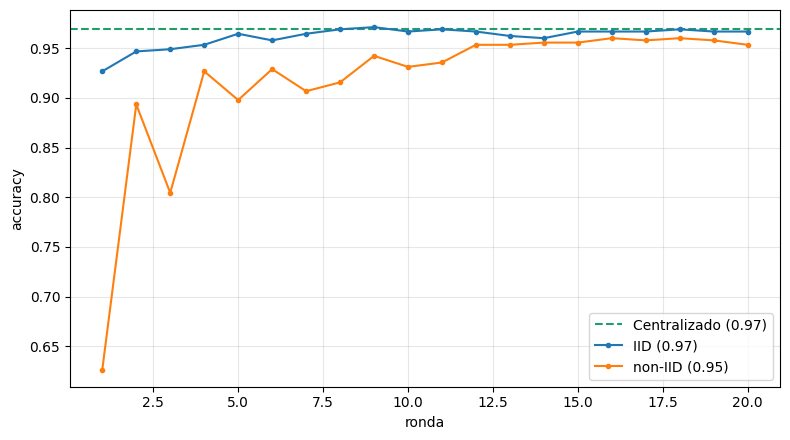

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4.5))
plt.axhline(acc_central, ls="--", color="#1F9D6B", label=f"Centralizado ({acc_central:.2f})")
plt.plot(range(1,len(hist_iid)+1),  hist_iid,  "-o", ms=3, label=f"IID ({hist_iid[-1]:.2f})")
plt.plot(range(1,len(hist_niid)+1), hist_niid, "-o", ms=3, label=f"non-IID ({hist_niid[-1]:.2f})")
plt.xlabel("ronda"); plt.ylabel("accuracy"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 6. (Opcional) Privacidad diferencial

Agrega ruido a los pesos agregados y mide cómo cae la accuracy.

sigma= 0.0: accuracy final=0.969
sigma=0.05: accuracy final=0.958
sigma= 0.1: accuracy final=0.927


sigma= 0.2: accuracy final=0.891


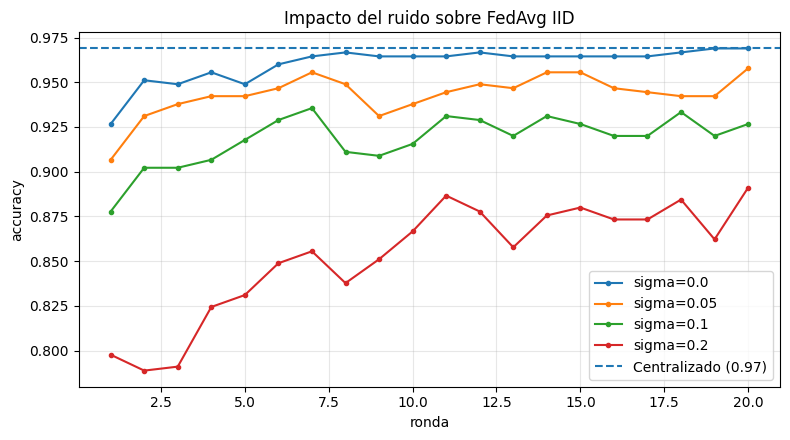

In [7]:
def federado_con_ruido(clientes, sigma, R=20, frac=0.4, epocas=25, lr=0.5, seed=0):
    """Simulación didáctica: agrega ruido gaussiano a los parámetros globales tras FedAvg.
    No sustituye un mecanismo formal de DP (faltan clipping y accounting de privacidad).
    """
    rng_dp = np.random.RandomState(seed)
    W, b = init_modelo()
    K = len(clientes)
    m = max(1, int(frac * K))
    hist = []
    for _ in range(R):
        sel = rng_dp.choice(K, m, replace=False)
        ups = [entrenar_local(W, b, *clientes[i][:2], epocas, lr) for i in sel]
        W, b = fedavg(ups)
        if sigma > 0:
            W = W + rng_dp.normal(0, sigma, size=W.shape)
            b = b + rng_dp.normal(0, sigma, size=b.shape)
        hist.append(accuracy(W, b))
    return W, b, hist

sigmas = [0.0, 0.05, 0.1, 0.2]
resultados_dp = {}
for sigma in sigmas:
    _, _, hist_dp = federado_con_ruido(clientes_iid, sigma=sigma, seed=1)
    resultados_dp[sigma] = hist_dp
    print(f"sigma={sigma:>4}: accuracy final={hist_dp[-1]:.3f}")

plt.figure(figsize=(8, 4.5))
for sigma, hist_dp in resultados_dp.items():
    plt.plot(range(1, len(hist_dp)+1), hist_dp, marker="o", ms=3, label=f"sigma={sigma}")
plt.axhline(acc_central, ls="--", label=f"Centralizado ({acc_central:.2f})")
plt.xlabel("ronda")
plt.ylabel("accuracy")
plt.title("Impacto del ruido sobre FedAvg IID")
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()


### Reflexión

El modelo centralizado alcanzó **0.969** de accuracy y FedAvg con partición **IID 0.967**, una pérdida de sólo **0.002** (0.2 puntos porcentuales), por lo que en este caso el costo de mantener los datos distribuidos fue muy bajo. Con datos **non-IID** la accuracy final bajó a **0.953**, una diferencia de **0.016** respecto del centralizado, y la curva fue menos estable porque cada cliente observa distribuciones locales sesgadas. Al agregar ruido, la accuracy cayó de **0.969** con `sigma=0` a **0.958**, **0.927** y **0.891** para `sigma=0.05`, `0.1` y `0.2`, mostrando el trade-off privacidad-utilidad. En un sistema real usaría clipping, privacidad diferencial formal y *privacy accounting*. El aprendizaje federado sería orgánico cuando los datos pertenecen a organizaciones o dispositivos que no pueden centralizarlos; si todos los datos ya pueden concentrarse, incorporarlo sería forzado y sumaría complejidad sin una ganancia clara.
